# Week 6-3 · PBQ-02 — Python Basics for Quants
**Module:** Python Basics & Its Quant Ecosystem · **Instructor:** Ashutosh Dwivedi

Your second Python lecture. It (1) recaps data types & structures, control flow and functions, then
(2) introduces the two **workhorses** of quant research — **NumPy** and **pandas** — and ends with the
**common calculations** you'll reuse in every back-test. This notebook reproduces the whole lecture on the
**real TCS.NS daily data** that ships with the class (`TCS.NS.csv`, 1233 rows, Nov-2015 → Nov-2020).

## 1. Data types & structures recap
Syntax is everything: `2` is an int, `2.0` a float, quotes make a string, a comparison makes a bool.

In [1]:
a = 2;        print("a   =", a,   "->", type(a).__name__)
b = 2.0;      print("b   =", b,   "->", type(b).__name__)
c = "TCS";    print("c   =", c,   "->", type(c).__name__)
d = (3 > 2);  print("d   =", d,   "->", type(d).__name__)

a   = 2 -> int
b   = 2.0 -> float
c   = TCS -> str
d   = True -> bool


### Lists, tuples, dicts, sets
A list is **heterogeneous** and mutable; a tuple is immutable; a dict gives **context** via key→value; a
set keeps only **unique** values and ignores order.

In [2]:
quote_list  = ["TCS", 1175.72, 1520352]            # symbol, price, volume (mixed types)
quote_tuple = ("TCS", 1175.72, 1520352)            # same, immutable
quote_dict  = {"symbol":"TCS", "last_price":1175.72, "volume":1520352}
print("list :", quote_list)
print("tuple:", quote_tuple)
print("dict last_price:", quote_dict["last_price"])      # access by key = self-documenting
print("set  :", {"a","u","i","a"})                       # duplicate 'a' collapses
print("order matters? list:", ["a","u"]==["u","a"], " set:", {"a","u"}=={"u","a"})

list : ['TCS', 1175.72, 1520352]
tuple: ('TCS', 1175.72, 1520352)
dict last_price: 1175.72
set  : {'a', 'i', 'u'}
order matters? list: False  set: True


## 2. Methods vs attributes
A **method** is a function you call (`list.append()`); an **attribute** is a stored value. `append` exists
on lists but not on tuples — tuples are immutable.

In [3]:
players = ["Messi", "Ronaldo"]
players.append("Neymar")          # method: mutates the list
print("after append:", players)
try:
    ("Messi", "Ronaldo").append("Neymar")    # tuples have no append
except AttributeError as e:
    print("tuple append ->", e)

after append: ['Messi', 'Ronaldo', 'Neymar']
tuple append -> 'tuple' object has no attribute 'append'


## 3. for loop + if / elif / else: a GDP trading signal
Buy if GDP growth > 7, hold if = 7, sell if < 7.

In [4]:
gdp = [7.2, 7, 8, 6.6]
signal = []
for g in gdp:
    if g > 7:
        signal.append("buy")
    elif g < 7:
        signal.append("sell")
    else:
        signal.append("hold")
print(list(zip(gdp, signal)))

[(7.2, 'buy'), (7, 'hold'), (8, 'buy'), (6.6, 'sell')]


### One-line if (ternary)
Same decision, fewer lines.

In [5]:
last_price, avg_price = 8, 10
out = "long" if last_price > avg_price else ("short" if last_price < avg_price else "hold")
print(out)

short


## 4. List comprehension
`[expression for item in list]` — build a new list in one line. The GDP signals become a one-liner.

In [6]:
squares = [i*i for i in [2,3,4,5]]
print("squares:", squares)
signal2 = ["buy" if g > 7 else ("sell" if g < 7 else "hold") for g in gdp]
print("signals (comprehension):", signal2)
import numpy as np
prices = [100, 102, 99, 105]
log_prices = [np.log(p) for p in prices]
print("log prices:", [round(x,4) for x in log_prices])

squares: [4, 9, 16, 25]
signals (comprehension): ['buy', 'hold', 'buy', 'sell']


log prices: [np.float64(4.6052), np.float64(4.625), np.float64(4.5951), np.float64(4.654)]


## 5. while loop + break / continue
A counter loop printing each month, then flow-control keywords.

In [7]:
month = 1
months = []
while month <= 12:
    months.append(f"{month}/2025")
    month += 1                       # MUST update the counter or you loop forever
print(months)

kept = []
for i in range(10):
    if i == 2:
        break                        # stop the loop entirely
    kept.append(i)
print("break at 2 ->", kept)

skipped = []
for i in range(10):
    if i == 5:
        continue                     # skip just this iteration
    skipped.append(i)
print("continue skips 5 ->", skipped)

['1/2025', '2/2025', '3/2025', '4/2025', '5/2025', '6/2025', '7/2025', '8/2025', '9/2025', '10/2025', '11/2025', '12/2025']
break at 2 -> [0, 1]
continue skips 5 -> [0, 1, 2, 3, 4, 6, 7, 8, 9]


## 6. Functions: def / return, and lambda
A function is a reusable machine: inputs in, output **returned** (not just printed).

In [8]:
def my_custom_function(x, y, z):
    k = x**2 + y**2 - z
    return k
print("f(2,3,1) =", my_custom_function(2,3,1))

def negative_or_not(n):
    return "negative number" if n < 0 else "non negative number"
print(negative_or_not(-5))

# lambda: anonymous one-liner, not saved to a named def
neg = lambda x: "negative" if x < 0 else "non negative"
print("lambda(-3) =", neg(-3))

f(2,3,1) = 12
negative number
lambda(-3) = negative


## 7. Libraries & the OS module
Reusable code packaged together = a **library**. Some ship built-in (`os`), some are installed (`numpy`).

In [9]:
import os
print("current working directory:")
print(" ", os.getcwd())
# dir(os) lists what's inside; show a few familiar names
print("a few os members:", [m for m in dir(os) if m in ("getcwd","chdir","listdir","path")])

current working directory:
  C:\Users\hsaeed1\Downloads\EPAT\learning\Week 6-3 PBQ-02 Python Basics for Quants code
a few os members: ['chdir', 'getcwd', 'listdir', 'path']


## 8. NumPy — the numeric workhorse
Python lists don't do element-wise maths (`a+b` concatenates!). NumPy arrays do **vectorized** operations
at C speed.

In [10]:
import numpy as np
print("numpy version:", np.__version__)
a = [1,2,3,4,5]; b = [6,7,8,9,10]
print("list a + b (concatenates!):", a + b)
A = np.array(a); B = np.array(b)
print("array A + B (element-wise):", A + B)
print("array A * B (element-wise):", A * B)

numpy version: 2.3.5
list a + b (concatenates!): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
array A + B (element-wise): [ 7  9 11 13 15]
array A * B (element-wise): [ 6 14 24 36 50]


### Ways to build arrays

In [11]:
print("linspace(1,10,5):", np.linspace(1, 10, 5))         # 5 equally spaced incl. endpoint
print("arange(0,4,0.5):", np.arange(0, 4, 0.5))           # step, endpoint excluded
print("zeros(5):", np.zeros(5))
print("ones(5):", np.ones(5))

linspace(1,10,5): [ 1.    3.25  5.5   7.75 10.  ]
arange(0,4,0.5): [0.  0.5 1.  1.5 2.  2.5 3.  3.5]
zeros(5): [0. 0. 0. 0. 0.]
ones(5): [1. 1. 1. 1. 1.]


### Speed: array vs list (%timeit)
The whole point of NumPy — same work, several times faster.

In [12]:
lst = [i for i in range(1000)]
arr = np.array(lst)
print("max on a list:")
%timeit max(lst)
print("max on an array:")
%timeit arr.max()

max on a list:


7.45 μs ± 53.1 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
max on an array:


1.53 μs ± 26.5 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


### Random samples + seeding
Monte-Carlo needs random draws; a **seed** makes them reproducible.

In [13]:
rng_demo = np.random.normal(0, 1, 10000)     # standard normal
print("mean ~0:", round(rng_demo.mean(), 3), " std ~1:", round(rng_demo.std(), 3))

np.random.seed(17)
first  = np.random.randint(1, 10, 5)
np.random.seed(17)
second = np.random.randint(1, 10, 5)
print("seed=17 reproducible:", first, "==", second, "->", np.array_equal(first, second))

mean ~0: 0.003  std ~1: 1.008
seed=17 reproducible: [2 7 7 1 7] == [2 7 7 1 7] -> True


### 2-D arrays: ndim, shape, dtype, and np.where

In [14]:
M = np.array([[2,4,6],[6,8,10]])
print("ndim:", M.ndim, " shape:", M.shape, " dtype:", M.dtype)
x = np.array([1,5,8])
cond = (x < 6) & (x > 3)
print("condition:", cond)
print("np.where(buy/sell):", np.where(x < 6, "buy", "sell"))
print("np.where(locations only):", np.where(x == 5))

ndim: 2  shape: (2, 3)  dtype: int64
condition: [False  True False]
np.where(buy/sell): ['buy' 'buy' 'sell']
np.where(locations only): (array([1]),)


## 9. pandas — Series & DataFrame
pandas (**pan**el **da**ta) is built on top of NumPy. A **Series** is 1-D (like one labelled column); a
**DataFrame** is 2-D (a spreadsheet).

In [15]:
import pandas as pd
returns = pd.Series([0.05, -0.02, 0.03, 0.01, -0.01],
                    index=["Mon","Tue","Wed","Thu","Fri"])
print(returns)
print("\nThursday return:", returns["Thu"])
print("describe:\n", returns.describe())

Mon    0.05
Tue   -0.02
Wed    0.03
Thu    0.01
Fri   -0.01
dtype: float64

Thursday return: 0.01
describe:
 count    5.000000
mean     0.012000
std      0.028636
min     -0.020000
25%     -0.010000
50%      0.010000
75%      0.030000
max      0.050000
dtype: float64


## 10. Read the real TCS data
`pd.read_csv` with `index_col='Date'`, `parse_dates=True`, `dayfirst=True` (dates are dd/mm/yyyy).

In [16]:
df = pd.read_csv("TCS.NS.csv", index_col="Date", parse_dates=True, dayfirst=True)
print("shape:", df.shape)
print("columns:", list(df.columns))
print(df.head(3))

shape: (1233, 7)
columns: ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Direction']
                   Open         High          Low        Close    Adj Close  \
Date                                                                          
2015-11-18  1194.449951  1194.449951  1173.000000  1175.719971  1038.072876   
2015-11-19  1182.680054  1190.800049  1176.000000  1181.280029  1042.982178   
2015-11-20  1183.250000  1211.780029  1180.969971  1199.180054  1058.786377   

               Volume Direction  
Date                             
2015-11-18  1520352.0       NaN  
2015-11-19  1866906.0        UP  
2015-11-20  2012126.0        UP  


### head / tail / column selection / row slicing

In [17]:
print("tail(2):\n", df.tail(2)[["Close","Volume"]])
print("\ntype of df['High']:", type(df["High"]).__name__)            # Series
print("type of df[['High','Low']]:", type(df[["High","Low"]]).__name__)  # DataFrame
print("\nrows 5:8 (Close):\n", df["Close"].iloc[5:8])

tail(2):
                   Close     Volume
Date                              
2020-11-13  2656.850098  2548093.0
2020-11-17  2666.050049  2827273.0

type of df['High']: Series
type of df[['High','Low']]: DataFrame

rows 5:8 (Close):
 Date
2015-11-26    1172.780029
2015-11-27    1176.680054
2015-11-30    1186.780029
Name: Close, dtype: float64


### Create a new column: daily range = High − Low (a volatility proxy)

In [18]:
df["Range"] = df["High"] - df["Low"]
print(df[["High","Low","Range"]].head(3))
print("\nbiggest range day (COVID volatility):")
print(df["Range"].idxmax().date(), "->", round(df["Range"].max(), 2), "rupees")

                   High          Low      Range
Date                                           
2015-11-18  1194.449951  1173.000000  21.449951
2015-11-19  1190.800049  1176.000000  14.800049
2015-11-20  1211.780029  1180.969971  30.810058

biggest range day (COVID volatility):
2020-03-13 -> 313.95 rupees


### Summary statistics

In [19]:
print("Close mean:", round(df['Close'].mean(), 2))
print("Close std :", round(df['Close'].std(), 2))
print(df[["Close","Range","Volume"]].describe().round(2))

Close mean: 1680.17
Close std : 449.2
         Close    Range       Volume
count  1232.00  1232.00      1232.00
mean   1680.17    37.80   2952525.93
std     449.20    24.75   3098947.08
min    1050.57     6.10     86822.00
25%    1239.04    21.25   1720676.00
50%    1725.68    31.72   2415503.00
75%    2075.71    47.63   3418828.50
max    2830.00   313.95  88067154.00


### Drop a column (axis=1)
`drop` returns a copy unless `inplace=True` (or you reassign).

In [20]:
trimmed = df.drop(["Adj Close","Direction"], axis=1)
print("after drop:", list(trimmed.columns))
print("original untouched:", list(df.columns))

after drop: ['Open', 'High', 'Low', 'Close', 'Volume', 'Range']
original untouched: ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Direction', 'Range']


## Key takeaways
- **Syntax decides type:** `2` int, `2.0` float, quotes string, comparison bool. Choose the structure for the job — list (mutable), tuple (immutable), dict (context), set (unique).
- **Method vs attribute:** `.append()` is a method (call it); `.shape` is an attribute (read it). Tuples have no `.append`.
- **Control flow:** `for`/`while` loops, `if/elif/else`, `break`/`continue`; **list comprehensions** compress a loop into one line.
- **Functions** package reusable logic (`def` … `return`); **lambda** is a one-line anonymous version.
- **NumPy** gives fast vectorized arrays (`array`, `linspace`, `arange`, `zeros/ones`), random sampling with a reproducible **seed**, `ndim/shape/dtype`, and `np.where` (Excel-style IF). Arrays beat lists on speed.
- **pandas** (`Series`, `DataFrame`) is built on NumPy: `read_csv` with `index_col`/`parse_dates`/`dayfirst`, `head/tail`, column selection (`df['c']` Series vs `df[['c']]` DataFrame), new columns via vectorized maths, `describe`, `drop`. On real TCS data the daily range spikes hugely during the March-2020 COVID crash.

---

# Additive Resource Section: pandas Quant Calculations and Data Hygiene

The original practice cells above are preserved. The following cells add the late-lecture/source-notebook material that was missing from the initial study pack.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("TCS.NS.csv")
df = pd.read_csv(DATA_PATH, index_col="Date", parse_dates=True, dayfirst=True).sort_index()
print(df.shape)
df.head()

(1233, 7)


,Open,High,Low,Close,Adj Close,Volume,Direction
Date,,,,,,,
2015-11-18,1194.449951,1194.449951,1173.000000,1175.719971,1038.072876,1520352.0,NaN
2015-11-19,1182.680054,1190.800049,1176.000000,1181.280029,1042.982178,1866906.0,UP
2015-11-20,1183.250000,1211.780029,1180.969971,1199.180054,1058.786377,2012126.0,UP
2015-11-23,1202.650024,1206.699951,1191.119995,1195.530029,1055.563843,1088082.0,DOWN
2015-11-24,1190.030029,1196.219971,1182.750000,1183.969971,1045.357300,998640.0,DOWN


## 1. Audit the DataFrame before analysis

`df.info()` tells you row count, non-null counts, data types, and memory use. `df.describe()` gives the numeric summary. `df.isnull().sum()` turns the missing-value audit into a reusable Series.

The missing-value count is separated from `describe()` because it is a decision input for data cleaning.


In [2]:
df.info()
summary = df.describe().round(2)
missing = df.isnull().sum()
summary

<class 'pandas.DataFrame'>
DatetimeIndex: 1233 entries, 2015-11-18 to 2020-11-17
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       1232 non-null   float64
 1   High       1232 non-null   float64
 2   Low        1232 non-null   float64
 3   Close      1232 non-null   float64
 4   Adj Close  1232 non-null   float64
 5   Volume     1232 non-null   float64
 6   Direction  1232 non-null   str    
dtypes: float64(6), str(1)
memory usage: 77.1 KB


,Open,High,Low,Close,Adj Close,Volume
count,1232.00,1232.00,1232.00,1232.00,1232.00,1232.00
mean,1680.70,1699.14,1661.34,1680.17,1596.08,2952525.93
std,450.39,455.59,443.92,449.20,473.53,3098947.08
min,1058.45,1070.00,1025.95,1050.57,961.71,86822.00
25%,1239.99,1249.79,1228.04,1239.04,1133.21,1720676.00
50%,1725.48,1750.95,1703.50,1725.68,1635.43,2415503.00
75%,2077.33,2096.25,2052.67,2075.71,2008.76,3418828.50
max,2845.00,2885.00,2812.20,2830.00,2817.99,88067154.00


In [3]:
missing

Open         1
High         1
Low          1
Close        1
Adj Close    1
Volume       1
Direction    1
dtype: int64

## 2. Select rows and columns deliberately

Use `[]` for columns and simple boolean masks, `.loc[]` for labels/dates, and `.iloc[]` for integer positions. In `.loc`, the end date is included. In `.iloc`, the stop position is excluded.

In [4]:
covid_close_range = df.loc["2020-03-01":"2020-06-30", ["Close", "High", "Low", "Volume"]].copy()
covid_close_range["Range"] = covid_close_range["High"] - covid_close_range["Low"]
print(covid_close_range.shape)
covid_close_range.head()

(80, 5)

,Close,High,Low,Volume,Range
Date,,,,,
2020-03-02,2001.300049,2053.949951,1985.699951,2667076.0,68.250000
2020-03-03,2036.199951,2060.000000,2012.000000,2757585.0,48.000000
2020-03-04,2083.199951,2094.449951,2025.000000,3237002.0,69.449951
2020-03-05,2125.050049,2147.750000,2084.050049,3937056.0,63.699951
2020-03-06,2116.449951,2123.649902,2071.600098,2595027.0,52.049804


Now compare position-based slicing with boolean filters.


In [5]:
position_slice = df.iloc[30:50, 1:3]
condition_1 = df["Open"] < 1200
condition_2 = (df["High"] - df["Low"]) < 20
condition_3 = df["Volume"] > 1_500_000
filtered = df[condition_1 & condition_2 & condition_3]
print("iloc slice shape:", position_slice.shape)
print("filtered rows:", filtered.shape[0])
filtered.head()

iloc slice shape: (20, 2)
filtered rows: 54


,Open,High,Low,Close,Adj Close,Volume,Direction
Date,,,,,,,
2015-11-19,1182.680054,1190.800049,1176.000000,1181.280029,1042.982178,1866906.0,UP
2015-11-27,1174.000000,1179.719971,1166.250000,1176.680054,1038.920654,1737206.0,UP
2015-12-01,1181.449951,1189.030029,1178.530029,1180.949951,1042.690430,1721994.0,DOWN
2015-12-02,1189.000000,1189.050049,1173.250000,1182.599976,1044.147461,1640296.0,UP
2015-12-03,1180.000000,1186.500000,1173.500000,1175.380005,1037.772705,2283358.0,DOWN


## 3. Common quant calculations

The lecture's common calculations are small pandas methods with big backtesting consequences: `diff`, `pct_change`, `shift`, `rolling`, and `ewm`. Notice that rolling windows naturally create warm-up `NaN` values.

In [6]:
work = df.copy()
work["Range"] = work["High"] - work["Low"]
work["Close_Change"] = work["Close"].diff()
work["Return_Pct"] = 100 * work["Close"].pct_change()
work["Log_Return"] = np.log(work["Close"]).diff()
work["Previous_Close"] = work["Close"].shift(1)
work["Next_Close_Demo"] = work["Close"].shift(-1)  # demo only: future data creates look-ahead bias in signals
work["MA_5"] = work["Close"].rolling(window=5).mean()
work["MA_100"] = work["Close"].rolling(window=100).mean()
work["EMA_20"] = work["Close"].ewm(span=20, adjust=False).mean()
work[["Close", "Close_Change", "Return_Pct", "Log_Return", "Previous_Close", "Next_Close_Demo", "MA_5", "MA_100", "EMA_20"]].head(12).round(4)

,Close,Close_Change,Return_Pct,Log_Return,Previous_Close,Next_Close_Demo,MA_5,MA_100,EMA_20
Date,,,,,,,,,
2015-11-18,1175.7200,NaN,NaN,NaN,NaN,1181.2800,NaN,NaN,1175.7200
2015-11-19,1181.2800,5.5601,0.4729,0.0047,1175.7200,1199.1801,NaN,NaN,1176.2495
2015-11-20,1199.1801,17.9000,1.5153,0.0150,1181.2800,1195.5300,NaN,NaN,1178.4334
2015-11-23,1195.5300,-3.6500,-0.3044,-0.0030,1199.1801,1183.9700,NaN,NaN,1180.0616
2015-11-24,1183.9700,-11.5601,-0.9669,-0.0097,1195.5300,1172.7800,1187.136,NaN,1180.4338
2015-11-26,1172.7800,-11.1899,-0.9451,-0.0095,1183.9700,1176.6801,1186.548,NaN,1179.7049
2015-11-27,1176.6801,3.9000,0.3325,0.0033,1172.7800,1186.7800,1185.628,NaN,1179.4168
2015-11-30,1186.7800,10.1000,0.8583,0.0085,1176.6801,1180.9500,1183.148,NaN,1180.1181
2015-12-01,1180.9500,-5.8301,-0.4913,-0.0049,1186.7800,1182.6000,1180.232,NaN,1180.1973


Plot the rolling features after creating them so the warm-up period and trend behavior are visible.


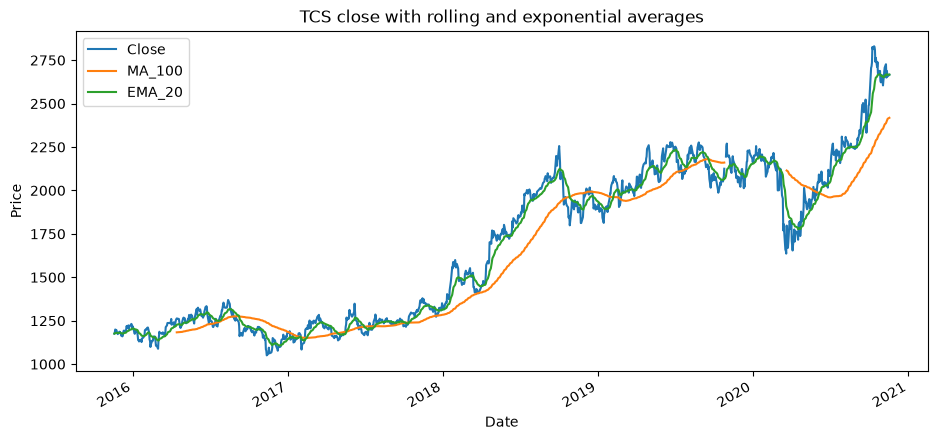

In [7]:
ax = work[["Close", "MA_100", "EMA_20"]].plot(figsize=(11, 5), title="TCS close with rolling and exponential averages")
ax.set_ylabel("Price")
plt.show()

## 4. Missing data: prefer past information in time series

For price/time-series metrics, the lecture default is forward fill when you need an estimate: use the last available value because it was known at that time. Avoid backfill or full-column mean fills in trading signals because they can import future information.

In [8]:
missing_before = work.isnull().sum().sort_values(ascending=False)
work_ffill = work.ffill()
missing_after = work_ffill.isnull().sum().sort_values(ascending=False)
pd.DataFrame({"before_ffill": missing_before, "after_ffill": missing_after}).query("before_ffill > 0 or after_ffill > 0").head(12)

,before_ffill,after_ffill
Adj Close,1,0
Close,1,0
Close_Change,3,1
Direction,1,1
High,1,0
Log_Return,3,1
Low,1,0
MA_100,199,99
MA_5,9,4
Next_Close_Demo,2,0


## 5. Row-wise logic: `apply`, lambda, and `np.where`

Use vectorized operations when possible. `apply(axis=1)` is useful for custom row logic. `np.where` is the compact vectorized if/else form and can also be nested for three-way labels.

In [9]:
def high_volume_day(row):
    if row["Volume"] > 1_500_000:
        return "high_volume_day"
    return "low_volume_day"

work["Volume_Regime_Apply"] = work.apply(high_volume_day, axis=1)
work["Volume_Regime_Lambda"] = work.apply(lambda row: "HV day" if row["Volume"] > 1_500_000 else "LV day", axis=1)
work["Volume_Regime"] = np.where(work["Volume"] > 1_500_000, "HV", "LV")
work["MA_Signal"] = np.where(work["Close"] > work["MA_100"], 1, np.where(work["Close"] < work["MA_100"], -1, 0))
work[["Volume", "Volume_Regime_Apply", "Volume_Regime_Lambda", "Volume_Regime", "MA_Signal"]].head(10)

,Volume,Volume_Regime_Apply,Volume_Regime_Lambda,Volume_Regime,MA_Signal
Date,,,,,
2015-11-18,1520352.0,high_volume_day,HV day,HV,0
2015-11-19,1866906.0,high_volume_day,HV day,HV,0
2015-11-20,2012126.0,high_volume_day,HV day,HV,0
2015-11-23,1088082.0,low_volume_day,LV day,LV,0
2015-11-24,998640.0,low_volume_day,LV day,LV,0
2015-11-26,2915292.0,high_volume_day,HV day,HV,0
2015-11-27,1737206.0,high_volume_day,HV day,HV,0
2015-11-30,4100048.0,high_volume_day,HV day,HV,0
2015-12-01,1721994.0,high_volume_day,HV day,HV,0


Summarize the labels to check that the signal logic produced sensible groups.


In [10]:
regime_summary = work.groupby("Volume_Regime")["Return_Pct"].agg(["count", "mean", "std"]).round(4)
signal_counts = work["MA_Signal"].value_counts().sort_index()
print("MA signal counts:")
print(signal_counts)
regime_summary

MA signal counts:
MA_Signal
-1    312
 0    199
 1    722
Name: count, dtype: int64


,count,mean,std
Volume_Regime,,,
HV,1029,0.088,1.7364
LV,201,0.022,0.8952


## 6. Homework methods from the source notebook

The official notebook leaves `set_index`, `concat`, `groupby`, `corr`, and `query` as follow-up practice. The examples below keep them tied to TCS data.

In [11]:
# query: SQL-like row filter
large_down_days = work.query("Return_Pct < -3 and Volume > 1500000")

# corr: relationship among numeric columns
correlations = work[["Return_Pct", "Range", "Volume"]].corr().round(3)

# concat: stack two small samples for comparison
first_three = work.head(3).assign(sample="first")
last_three = work.tail(3).assign(sample="last")
comparison_sample = pd.concat([first_three, last_three])

print("large down days:", large_down_days.shape[0])
correlations

large down days: 36


,Return_Pct,Range,Volume
Return_Pct,1.000,0.033,0.000
Range,0.033,1.000,0.374
Volume,0.000,0.374,1.000


## 7. Save results back

Use `to_csv`, `to_excel`, `to_html`, `to_json`, and related methods after analysis. This notebook writes a compact CSV sample into the validation scratch folder when executed there.

In [12]:
output_cols = ["Open", "High", "Low", "Close", "Volume", "Return_Pct", "MA_100", "Volume_Regime", "MA_Signal"]
export_path = Path("pbq02_tcs_enriched_sample.csv")
work[output_cols].tail(20).round(4).to_csv(export_path)
print(export_path.resolve())

C:\Users\hsaeed\Downloads\EPAT-Git\_validation_work\pbq02\notebook_exec_20260702_094614\pbq02_tcs_enriched_sample.csv
